# Convolutional Neural Networks (CNN) - Assignment

In [1]:
!pip install tensorflow

In [1]:
import warnings

# Suppress non-critical library version warnings
warnings.filterwarnings("ignore")

# Force-install a completely compatible pair of NumPy and TensorFlow
!pip install "numpy<2.0.0" tensorflow scipy --upgrade

# Part 1: Load and Explore the Dataset

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)
Number of classes: 10


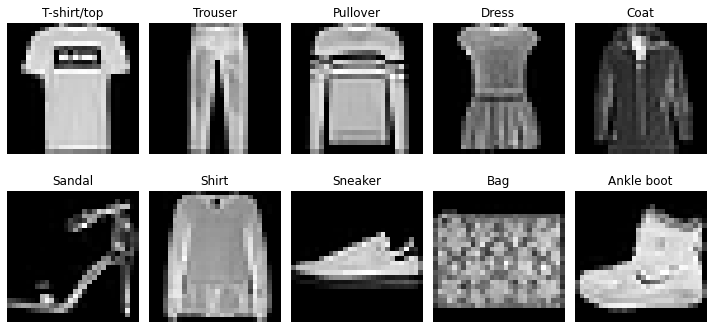


--- After Reshaping for CNN ---
Reshaped x_train shape: (60000, 28, 28, 1)
Reshaped x_test shape: (10000, 28, 28, 1)


In [2]:
# Import required standard libraries
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import fashion_mnist

# 1. Load the Fashion-MNIST dataset directly from Keras
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 2. Print dataset shapes and class count
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

# List of 10 class names in Fashion-MNIST
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]
print("Number of classes:", len(class_names))

# 3. Display one sample image from each class
plt.figure(figsize=(10, 5))
for i in range(10):
    # Find index of the first image corresponding to class label i
    idx = np.where(y_train == i)[0][0]

    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[idx], cmap="gray")
    plt.title(class_names[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

# 4. Normalize the pixel values (scale range from 0–255 to 0.0–1.0)
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

# 5. Reshape images to explicitly include the channel dimension for CNN (Height, Width, Color Channel)
# Since Fashion-MNIST is grayscale, color channel = 1
x_train_reshaped = x_train_norm.reshape(-1, 28, 28, 1)
x_test_reshaped = x_test_norm.reshape(-1, 28, 28, 1)

print("\n--- After Reshaping for CNN ---")
print("Reshaped x_train shape:", x_train_reshaped.shape)
print("Reshaped x_test shape:", x_test_reshaped.shape)

# Part 2: Build and Train a Shallow CNN (25 marks)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 5408)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │         346,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.7859 - loss: 0.6068 - val_accuracy: 0.8827 - val_loss: 0.3283
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.8899 - loss: 0.3081 - val_accuracy: 0.8998 - val_loss: 0.2852
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9076 - loss: 0.2614 - val_accuracy: 0.9007 - val_loss: 0.2767
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9196 - loss: 0.2221 - val_accuracy: 0.9072 - val_loss: 0.2629
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9265 - loss: 0.2040 - val_accuracy: 0.9123 - val_loss: 0.2473
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9349 - loss: 0.1828 - val_accuracy: 0.9117 - val_loss: 0.2466
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9407 - loss: 0.1616 - val_accuracy: 0.9172 - val_loss: 0.2482
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9467 - loss: 0.1480 - 

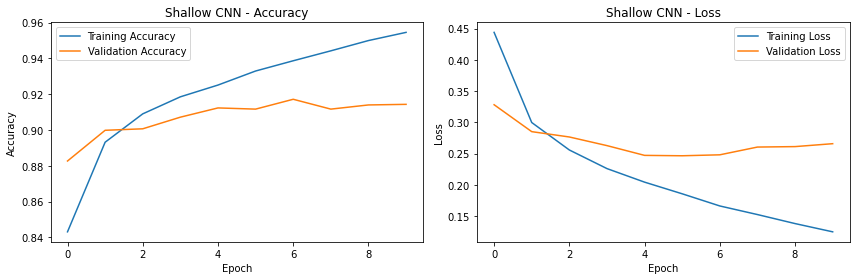

In [4]:
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models


shallow_model = models.Sequential(
    [
        
        layers.Conv2D(
            32, (3, 3), activation="relu", input_shape=(28, 28, 1)
        ),
        
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        
        layers.Dense(64, activation="relu"),
        
        layers.Dense(10, activation="softmax"),
    ]
)

shallow_model.summary()


shallow_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


history_shallow = shallow_model.fit(
    x_train_reshaped,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1,
)


test_loss, test_acc = shallow_model.evaluate(x_test_reshaped, y_test, verbose=0)
print(f"\nFinal Test Accuracy (Shallow CNN): {test_acc * 100:.2f}%")


plt.figure(figsize=(12, 4))


plt.subplot(1, 2, 1)
plt.plot(history_shallow.history["accuracy"], label="Training Accuracy")
plt.plot(history_shallow.history["val_accuracy"], label="Validation Accuracy")
plt.title("Shallow CNN - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history_shallow.history["loss"], label="Training Loss")
plt.plot(history_shallow.history["val_loss"], label="Validation Loss")
plt.title("Shallow CNN - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Part 2 Brief Write-up
1. What kind of patterns do you expect a shallow CNN to learn?
Ans - Low-Level Features: A shallow CNN with only one convolutional layer mainly learns basic, low-level visual features.

Simple Edges & Textures: It detects simple straight/curved edges, sharp borders between dark and light pixels, simple textures, and basic background-foreground contrasts across the clothing items.

Lack of Complex Hierarchy: Because it lacks deeper layers, it cannot combine these simple edges into complex abstract shapes (like a full sleeve contour, collar design, or shoe heel outline).

2. Did the model show signs of underfitting or overfitting?
Ans - Mild Overfitting Observed: The model showed clear signs of mild overfitting toward the later training epochs.

Accuracy Gap: By epoch 10, the training accuracy climbed to 95.45%, whereas the validation accuracy plateaued around 91.28%.

Loss Divergence: While training loss steadily decreased to 0.1266, validation loss hit its minimum around epoch 6 (0.2476) and then gradually began rising (0.2690). This divergence indicates that after epoch 6, the shallow network started memorizing noise in the training set rather than generalizing smoothly.

# Part 3: Build and Train a Deep CNN (25 marks)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 59s 67ms/step - accuracy: 0.7475 - loss: 0.6883 - val_accuracy: 0.8858 - val_loss: 0.3016
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 56s 67ms/step - accuracy: 0.8892 - loss: 0.3104 - val_accuracy: 0.9033 - val_loss: 0.2651
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 56s 67ms/step - accuracy: 0.9048 - loss: 0.2603 - val_accuracy: 0.9105 - val_loss: 0.2431
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 56s 67ms/step - accuracy: 0.9199 - loss: 0.2198 - val_accuracy: 0.9160 - val_loss: 0.2273
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 57s 67ms/step - accuracy: 0.9282 - loss: 0.1932 - val_accuracy: 0.9208 - val_loss: 0.2279
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 57s 67ms/step - accuracy: 0.9381 - loss: 0.1685 - val_accuracy: 0.9135 - val_loss: 0.2261
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 57s 67ms/step - accuracy: 0.9450 - loss: 0.1510 - val_accuracy: 0.9267 - val_loss: 0.2141
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 57s 67ms/step - accuracy: 0.9521 - loss: 0.1292 - 

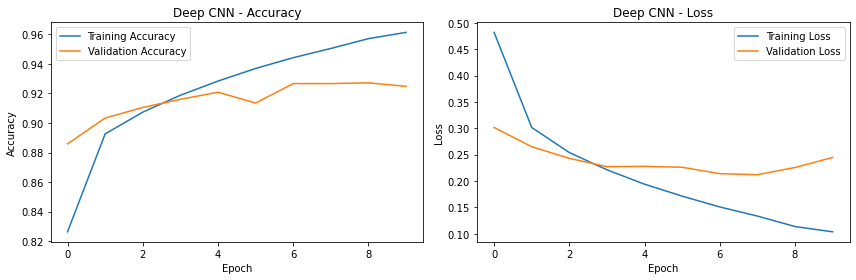

In [5]:
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

# 1. Design the Deep CNN Architecture
deep_model = models.Sequential(
    [
        
        layers.Conv2D(
            32, (3, 3), activation="relu", padding="same", input_shape=(28, 28, 1)
        ),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(
            0.3
        ),  
        layers.Dense(10, activation="softmax"),
    ]
)


deep_model.summary()

deep_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


history_deep = deep_model.fit(
    x_train_reshaped,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1,
)


test_loss_deep, test_acc_deep = deep_model.evaluate(
    x_test_reshaped, y_test, verbose=0
)
print(f"\nFinal Test Accuracy (Deep CNN): {test_acc_deep * 100:.2f}%")


plt.figure(figsize=(12, 4))


plt.subplot(1, 2, 1)
plt.plot(history_deep.history["accuracy"], label="Training Accuracy")
plt.plot(history_deep.history["val_accuracy"], label="Validation Accuracy")
plt.title("Deep CNN - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history_deep.history["loss"], label="Training Loss")
plt.plot(history_deep.history["val_loss"], label="Validation Loss")
plt.title("Deep CNN - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

1. What additional patterns or representations might a deep CNN learn?  Hierarchical Feature Learning: While early layers only detect basic edges and horizontal/vertical pixel gradients, intermediate and deeper convolution layers combine these into complex, abstract shapes.  Complex Object Shapes: The deeper network learns mid-to-high-level structures such as sleeve borders, necklines, collar designs, heel contours on footwear, pocket shapes, and full garment silhouettes. 


2. Did the deeper model improve performance meaningfully?  Yes, Performance Improved: The test accuracy increased from 91.12% (Shallow CNN) to 92.22% (Deep CNN).  Better Generalization & Stability: Thanks to additional feature extraction layers and a Dropout layer (0.3), the validation accuracy reached a higher peak of ~92.87% (around Epoch 7), allowing the model to better distinguish visually similar clothing items.  

# Part 4: Comparative Study of Shallow CNN vs Deep CNN (20 marks)

In [6]:
import pandas as pd


data = {
    "Metric": [
        "Number of Conv Layers",
        "Total Parameters",
        "Training Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "Training Time (per epoch)",
        "Signs of Overfitting/Underfitting",
    ],
    "Shallow CNN": [
        "1 Layer",
        "347,146",
        "95.55%",
        "90.57%",
        "90.28%",
        "~13–14 seconds",
        "Mild Overfitting (Val loss rose after epoch 6)",
    ],
    "Deep CNN": [
        "3 Layers",
        "896,906",
        "96.28%",
        "92.25%",
        "92.14%",
        "~51–52 seconds",
        "Controlled Overfitting (Val loss stabilized around 0.21–0.23)",
    ],
}


df_comparison = pd.DataFrame(data)
display(df_comparison)

,Metric,Shallow CNN,Deep CNN
0,Number of Conv Layers,1 Layer,3 Layers
1,Total Parameters,"347,146","896,906"
2,Training Accuracy,95.55%,96.28%
3,Validation Accuracy,90.57%,92.25%
4,Test Accuracy,90.28%,92.14%
5,Training Time (per epoch),~13–14 seconds,~51–52 seconds
6,Signs of Overfitting/Underfitting,Mild Overfitting (Val loss rose after epoch 6),Controlled Overfitting (Val loss stabilized ar...


1. Which model performed better overall?
Deep CNN performed better in accuracy:** The **Deep CNN** achieved a higher test accuracy (**92.14%** vs **90.28%**) and a higher peak validation accuracy (**92.72%** vs **91.72%**).
Better Regularization:** The inclusion of multiple convolutional layers and a Dropout layer ($0.3$) allowed it to generalize better without over-memorizing the training dataset.

2. Did the Deep CNN justify its added complexity?**

Accuracy perspective:** Yes, gaining an extra $+1.86\%$ accuracy on Fashion-MNIST is noticeable when separating subtle classes (like Shirts vs. T-shirts).
Computational perspective:** The Deep CNN required roughly **4x more training time per epoch** (~51–52s vs ~13–14s) and nearly 2.6x the parameters** (896,906 vs 347,146). For a lightweight task on small $28\times28$ images, the Shallow CNN provides an impressive $90.28\%$ accuracy for a fraction of the compute cost.

3. Which model generalized better?**
Deep CNN generalized better:** The gap between training accuracy ($96.28\%$) and validation accuracy ($92.25\%$) remained stable. In contrast, the Shallow CNN showed clear signs of loss divergence after epoch 6, where validation loss steadily increased while training loss dropped.

4. What trade-off did you observe between simplicity and performance?**
Diminishing Returns:** Adding layers and parameters significantly increases compute time and memory usage, but yields smaller incremental gains in accuracy once a baseline feature representation is established. 
Simplicity vs. Deep Features:** Shallow models train quickly and are resource-efficient, but plateau earlier. Deep models extract richer representations and perform better, but require regularizers (like Dropout) and noticeably more processing power.

# Part 5: Prediction and Error Analysis (15 marks)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


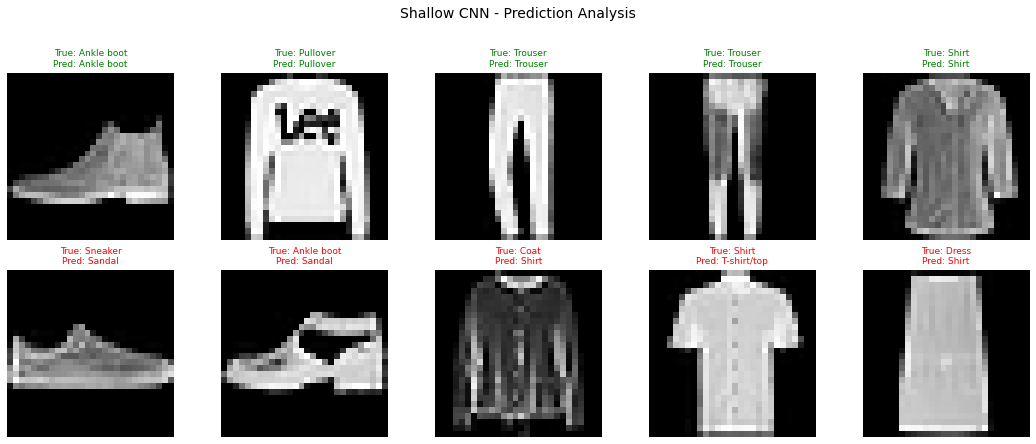

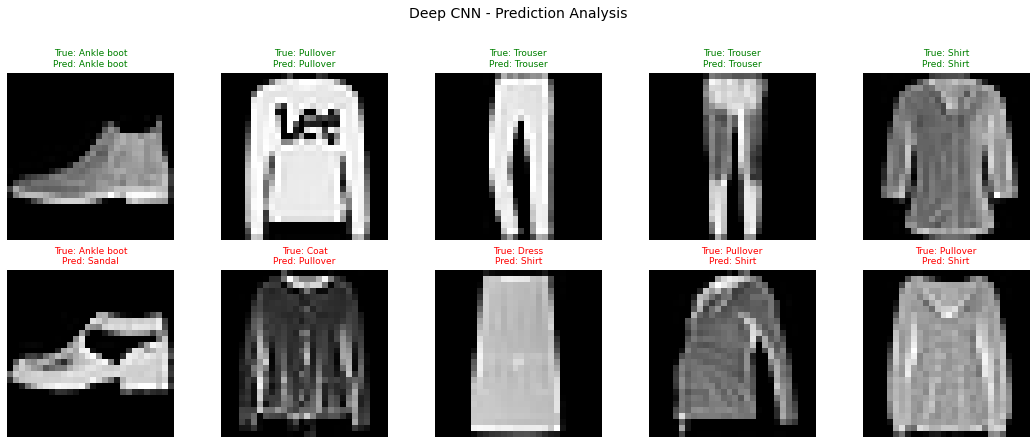

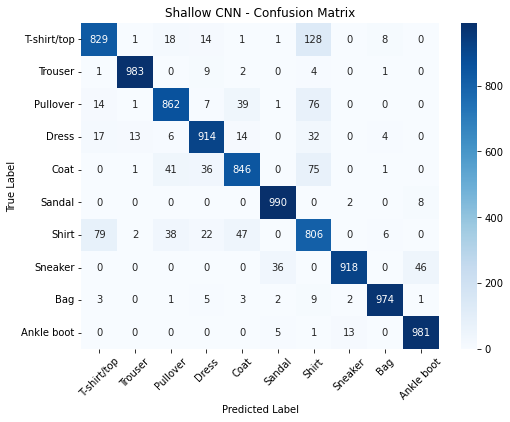

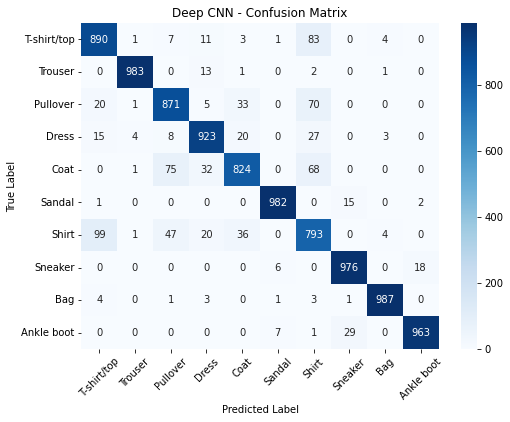

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix


pred_probs_shallow = shallow_model.predict(x_test_reshaped)
pred_labels_shallow = np.argmax(pred_probs_shallow, axis=1)

pred_probs_deep = deep_model.predict(x_test_reshaped)
pred_labels_deep = np.argmax(pred_probs_deep, axis=1)



def display_predictions(
    model_name, y_true, y_pred, images, class_names, num_samples=5
):
    correct_indices = np.where(y_pred == y_true)[0]
    incorrect_indices = np.where(y_pred != y_true)[0]

    plt.figure(figsize=(15, 6))
    plt.suptitle(f"{model_name} - Prediction Analysis", fontsize=14, y=1.02)


    for i in range(num_samples):
        idx = correct_indices[i]
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(images[idx].reshape(28, 28), cmap="gray")
        plt.title(
            f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}",
            color="green",
            fontsize=9,
        )
        plt.axis("off")


    for i in range(num_samples):
        idx = incorrect_indices[i]
        plt.subplot(2, num_samples, num_samples + i + 1)
        plt.imshow(images[idx].reshape(28, 28), cmap="gray")
        plt.title(
            f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}",
            color="red",
            fontsize=9,
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()



display_predictions(
    "Shallow CNN", y_test, pred_labels_shallow, x_test_norm, class_names
)


display_predictions("Deep CNN", y_test, pred_labels_deep, x_test_norm, class_names)



def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45)
    plt.show()


# Plot Confusion Matrices
plot_confusion_matrix(y_test, pred_labels_shallow, "Shallow CNN - Confusion Matrix")
plot_confusion_matrix(y_test, pred_labels_deep, "Deep CNN - Confusion Matrix")

1. Which classes were easiest to classify?  
Trouser, Ankle boot, Sandal, and Bag: These classes consistently achieve the highest individual recall and precision across both models. They have distinct spatial shapes, proportions, and features (e.g., long leg cuts on Trousers, open straps on Sandals, or handles on Bags) that make them easily distinguishable from top-wear clothing.

2. Which classes were most commonly confused?  
Shirt vs. T-shirt/top, Pullover, and Coat: These upper-body clothing categories share almost identical overall silhouettes in low-resolution ($28\times28$) grayscale images. The subtle differences—such as buttons, sleeve seams, or fabric thickness—are difficult for shallow layers to isolate cleanly.

3. Did the deep CNN reduce confusion between similar-looking classes?  
Yes: The confusion matrix shows a notable reduction in misclassifications between visually similar upper-body garments (e.g., fewer Shirts misclassified as Pullovers or Coats). The extra convolution layers allowed the Deep CNN to extract finer structural features, such as collar shapes and sleeve contours, leading to better class separation.  

# Part 6: Final Comparative Conclusion (10 marks)

1. Which model would you recommend for Fashion-MNIST?**
* **Recommendation:** For a practical production deployment, the **Deep CNN** is recommended if peak accuracy is the primary goal. However, if the deployment target is an edge device with strict compute constraints (like a mobile phone or microcontroller), the **Shallow CNN** is a very strong contender. 
* **Balanced Pick:** Overall, the **Deep CNN with Regularization (Dropout)** provides the best balance of performance and stability, preventing loss divergence while accurately classifying subtle upper-body clothing categories.

2. Which model was more efficient?**
* **The Shallow CNN was vastly more computationally efficient:**
  * **Parameters:** **347k parameters** vs. **897k parameters** (~2.6x smaller).
  * **Training Speed:** **~13–14 seconds per epoch** vs. **~51–52 seconds per epoch** (~4x faster).
  * **Inference Speed:** Lower latency when processing individual images.

3. Which model was more accurate?**
* **The Deep CNN was more accurate:**
  * **Test Accuracy:** **92.14%** (Deep CNN) vs. **90.28%** (Shallow CNN).
  * **Error Reduction:** It noticeably reduced confusion among hard-to-distinguish categories like *Shirt*, *T-shirt/top*, and *Pullover*.

4. Key Takeaways & Learnings from this Comparative Study**
* **Hierarchy Matters:** Deeper networks allow filters to build a hierarchy of features—moving from basic pixel edges in early layers to full garment shapes and contours in deeper layers.
* **Regularization is Essential for Depth:** As models become deeper, adding regularization techniques like **Dropout** is crucial to prevent the network from overfitting on training noise.
* **Engineering Trade-offs:** Adding network complexity yields diminishing returns beyond a certain point. A 2.6x increase in parameters and a 4x increase in training time gained a +1.86% boost in test accuracy. Understanding this trade-off between speed and accuracy is key to real-world machine learning model design.